In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

In [2]:
def load_data(picklefile):  
    f = open(picklefile, "rb") 
    data = pickle.load(f) 
    f.close() 
    return data 
(train_seq, val_seq, test_seq) = load_data("temperatures-2025.pkl")

## Part(i)

In [3]:
X_train, y_train = train_seq[:, :72, :], train_seq[:, 72:, :]
X_val,   y_val   = val_seq[:, :72, :],   val_seq[:, 72:, :]
X_test,  y_test  = test_seq[:, :72, :],  test_seq[:, 72:, :]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:", y_val.shape)
print("X_test: ", X_test.shape,  "y_test:", y_test.shape)

X_train: (1490, 72, 2) y_train: (1490, 12, 2)
X_val:   (109, 72, 2) y_val: (109, 12, 2)
X_test:  (105, 72, 2) y_test: (105, 12, 2)


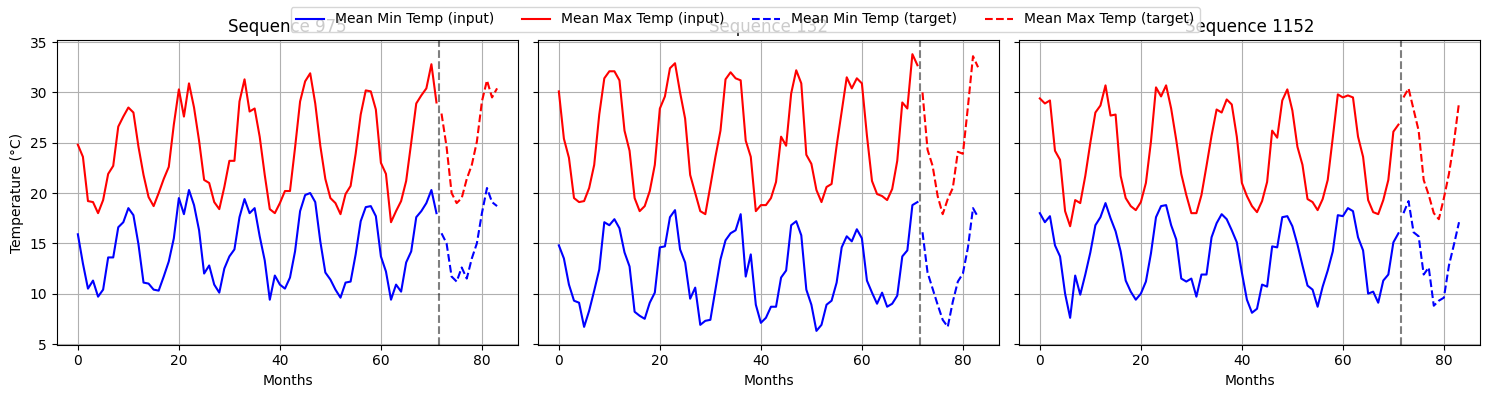

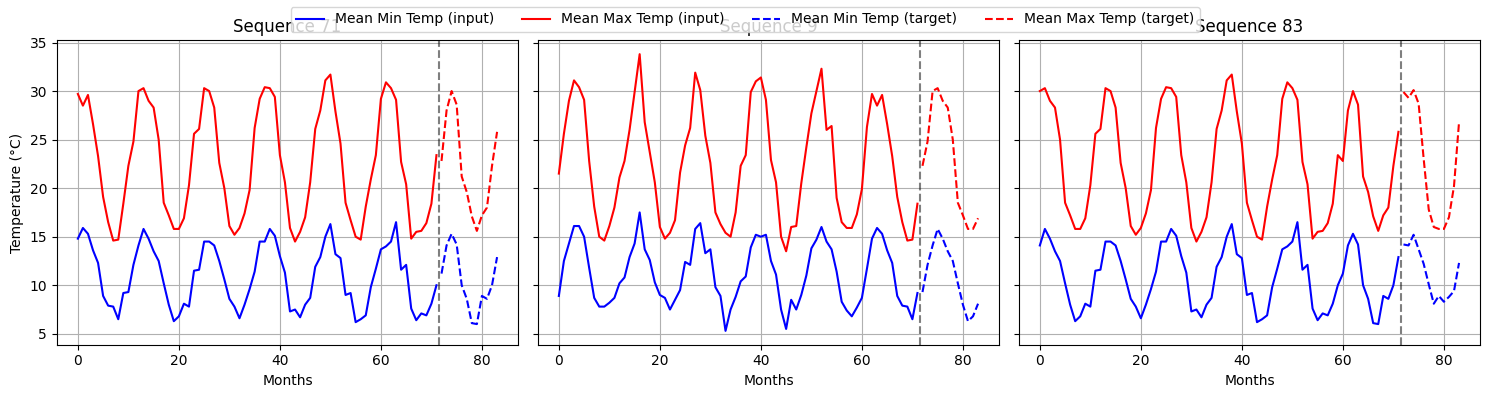

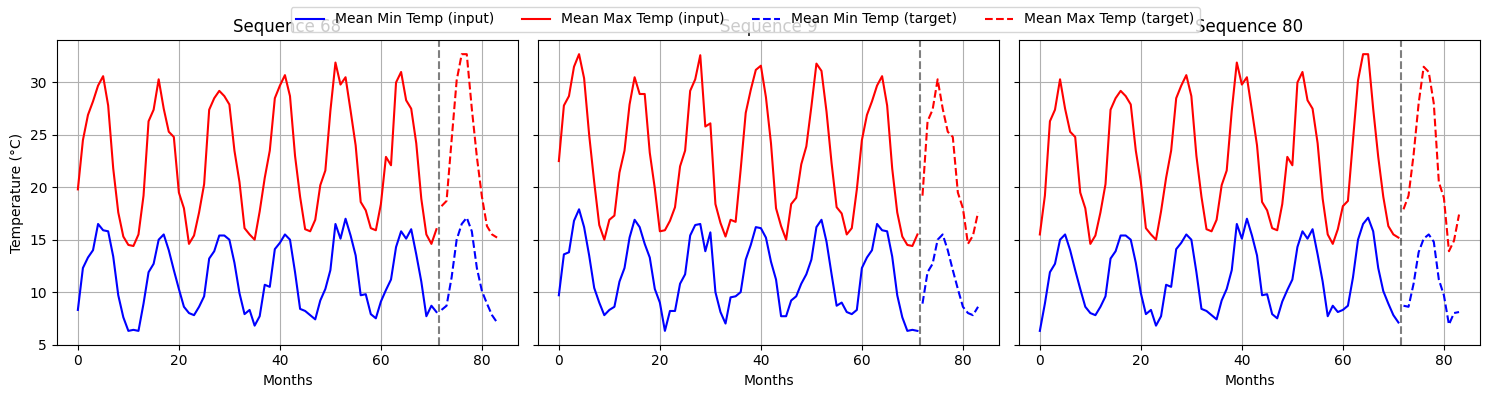

In [4]:
def display_temperatures(x=None, y=None, y_pred=None,
                         decoder=None, latent_dim=None, vae_samples=None,
                         num_samples=None,compare=None, seed=None):
    """
    Display:
    - GRU: Random input/target/predicted sequences (Min & Max temps)
    - VAE: Synthetic sequences from zero and random latent vectors
    """
    rng = np.random.default_rng(seed)
    tf.random.set_seed(seed)

    # === CASE 1: GRU visualization ===
    if x is not None and y is not None:
        x = x.numpy() if isinstance(x, tf.Tensor) else x
        y = y.numpy() if isinstance(y, tf.Tensor) else y
        if y_pred is not None:
            y_pred = y_pred.numpy() if isinstance(y_pred, tf.Tensor) else y_pred

        idx = rng.choice(len(x), size=num_samples, replace=False)
        fig, axes = plt.subplots(1, num_samples, figsize=(15, 4), sharey=True)

        for j, i in enumerate(idx):
            seq_x, seq_y = x[i], y[i]
            input_months = np.arange(len(seq_x))
            target_months = np.arange(len(seq_x), len(seq_x) + len(seq_y))
            ax = axes[j]

            # Input (solid)
            ax.plot(input_months, seq_x[:, 0], 'b-', label='Mean Min Temp (input)')
            ax.plot(input_months, seq_x[:, 1], 'r-', label='Mean Max Temp (input)')

            # Target (dashed)
            ax.plot(target_months, seq_y[:, 0], 'b--', label='Mean Min Temp (target)')
            ax.plot(target_months, seq_y[:, 1], 'r--', label='Mean Max Temp (target)')

            # Prediction (dotted)
            if y_pred is not None:
                seq_pred = y_pred[i]
                ax.plot(target_months, seq_pred[:, 0], 'b:', label='Mean Min Temp (pred)')
                ax.plot(target_months, seq_pred[:, 1], 'r:', label='Mean Max Temp (pred)')

            ax.axvline(x=len(seq_x)-0.5, color="k", linestyle="--", alpha=0.5)
            ax.set_title(f'Sequence {i}')
            ax.set_xlabel('Months')
            if j == 0:
                ax.set_ylabel('Temperature (°C)')
            ax.grid(True)

        # Combine and deduplicate legend
        handles, labels = axes[0].get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=4)
        plt.tight_layout()
        plt.show()
        return

    # === CASE 2: VAE synthetic visualization ===
    if decoder is not None:
        if vae_samples is None:
            vae_samples = 6

        # Zero-latent (mean) and random-latent (diverse) samples
        latent_dim = decoder.input_shape[-1] if latent_dim is None else latent_dim
        z_zero = tf.zeros(shape=(vae_samples, latent_dim))
        z_rand = tf.random.normal(shape=(vae_samples, latent_dim))

        x_zero = decoder.predict(z_zero, verbose=0)
        x_rand = decoder.predict(z_rand, verbose=0)
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
        fig.suptitle("Synthetic-latent", fontsize=16)
        for i, ax in enumerate(axes.ravel()):
            ax.plot(np.arange(x_rand.shape[1]), x_rand[i], lw=2)
            ax.set_title(f"Synth seq {i+1}")
            ax.set_xlabel("Months")
            ax.set_ylabel("Max Temp (°C)")
            ax.grid(True)

        fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
        fig.suptitle("Zero-latent", fontsize=16)
        for i, ax in enumerate(axes.ravel()):
            ax.plot(np.arange(x_zero.shape[1]), x_zero[i], lw=2)
            ax.set_title(f"Zero Seq {i+1}")
            ax.set_xlabel("Months")
            ax.set_ylabel("Max Temp (°C)")
            ax.grid(True)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()



display_temperatures(X_train, y_train, num_samples=3, seed=42)
display_temperatures(X_val, y_val, num_samples=3, seed=42)
display_temperatures(X_test, y_test, num_samples=3, seed=42)

The display_temperatures() function was implemented as a reusable visualisation tool for both displaying the data representation before GRU forecasting and for generating synthetic temperature sequences during VAE training.
It supports two modes of operation:

- Case 1 (GRU visualisation) – plots three randomly selected input–target sequences of mean minimum and maximum monthly temperatures. Solid lines represent the input window (past 72 months).Dashed lines show the ground-truth target (future 12 months). Dotted lines (enabled via the y_pred argument) display the model’s predicted sequence. A vertical dashed divider visually separates the input and forecast regions.

- Case 2 (VAE visualisation) – plots six synthetic temperature sequences decoded from random latent vectors, providing an intuitive view of how well the VAE learns realistic seasonal temperature patterns.

The function was designed to be modular and reusable.For GRU models (training, validation, and test visualisation):

- x : input temperature sequences (e.g., X_train, X_val, X_test) plotted as solid lines to represent past 72-month input data.

- y : target sequences (e.g., y_train, y_val, y_test) plotted as dashed lines to represent the 12-month ground truth.

- y_pred : predicted sequences from the GRU model which is plotted as dotted lines showing the model’s forecast results.

- num_samples : number of random sequences to display (default = 3).

- seed : random seed to ensure reproducible selection of sequences.

Examples:
- display_temperatures(X_train, y_train, num_samples=3, seed=42)
- display_temperatures(X_val, y_val, num_samples=3, seed=42)
- display_temperatures(X_test, y_test, y_pred, num_samples=3, seed=42)

For VAE synthetic sequence generation:

- decoder : the trained VAE decoder network used to reconstruct or generate sequences.
- latent_dim : the dimensionality of the latent vector (e.g., 8 or 12).
- vae_samples : number of synthetic sequences to generate (default = 6).
- seed : random seed for consistent latent sampling.

Examples: display_temperatures(decoder=decoder, latent_dim=12, vae_samples=6, seed=42)

In [5]:
def GRUmodel(model_type, output, input_length, target_length, num_features, units):
    if model_type == "gru":
        base = tf.keras.Sequential([
            tf.keras.layers.GRU(units, return_sequences=True, input_shape=(input_length, num_features), activation="relu"),
            tf.keras.layers.GRU(units, return_sequences=False, activation="relu")
        ])
        if output == "all":
            # Model 1: Predict all 12 months at once
            model = tf.keras.Sequential([
                base,
                tf.keras.layers.Dense(target_length * num_features),
                tf.keras.layers.Reshape((target_length, num_features))
            ])
        elif output == "one":
            # Model 2: Predict 1 month (to be rolled out later in a loop)
            model = tf.keras.Sequential([
                base,
                tf.keras.layers.Dense(num_features)
            ])
    elif model_type == "encdec":
        # ----- Encoder -----
        encoder_inputs = tf.keras.Input(shape=(input_length, num_features))
        encoder_gru1 = tf.keras.layers.GRU(units, return_sequences=True, return_state=True, activation="relu")
        encoder_seq1, encoder_state1 = encoder_gru1(encoder_inputs)
        encoder_gru2 = tf.keras.layers.GRU(units, return_sequences=False, return_state=True, activation="relu")
        _, encoder_state2 = encoder_gru2(encoder_seq1)

        # ----- Decoder -----
        decoder_inputs = tf.keras.Input(shape=(target_length, num_features))
        decoder_gru1 = tf.keras.layers.GRU(units, return_sequences=True, return_state=True, activation="relu")
        decoder_seq, _ = decoder_gru1(decoder_inputs, initial_state=encoder_state1)
        decoder_gru2 = tf.keras.layers.GRU(units, return_sequences=True, return_state=True, activation="relu")
        decoder_seq, _ = decoder_gru2(decoder_seq, initial_state=encoder_state2)
        decoder_dense = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(num_features))
        decoder_outputs = decoder_dense(decoder_seq)


        model = tf.keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)


    model.compile(optimizer=tf.keras.optimizers.Nadam(),
                  loss="mae", metrics=["mae"])
    return model


def train_model(model, output, X_train, y_train, X_val, y_val,
                epochs, batch_size, patience, verbose):
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

    # --- Model 2: One-step GRU ---
    if output == "one":
        y_train_in = y_train[:, 0, :]
        y_val_in   = y_val[:, 0, :]
        X_train_in, X_val_in = X_train, X_val

    # --- Model 3: Encoder–Decoder GRU ---
    elif output == "encdec":
        # Decoder inputs = last timestep from X + shifted y (teacher forcing)
        dec_train = np.concatenate([X_train[:, -1:, :], y_train[:, :-1, :]], axis=1).astype(np.float32)
        dec_val   = np.concatenate([X_val[:, -1:, :], y_val[:, :-1, :]], axis=1).astype(np.float32)

        X_train_in, y_train_in = [X_train, dec_train], y_train
        X_val_in,   y_val_in   = [X_val, dec_val], y_val

    # --- Model 1: Multi-step GRU ---
    else:
        X_train_in, y_train_in = X_train, y_train
        X_val_in,   y_val_in   = X_val, y_val

    # --- Train ---
    history = model.fit(
        X_train_in, y_train_in,
        validation_data=(X_val_in, y_val_in),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=verbose
    )
    return history

# Helper to plot learning curve
def plot_learning_curve(history):
    plt.figure(figsize=(8,4))
    hist = history.history

    # ---- Case 1: Models trained with MAE (e.g., GRU models 1–3) ----
    if 'mae' in hist or 'val_mae' in hist:
        if 'mae' in hist:
            plt.plot(hist['mae'], label='Train MAE')
        if 'val_mae' in hist:
            plt.plot(hist['val_mae'], label='Val MAE')
        plt.ylabel('Mean Absolute Error')
        plt.title('Learning Curve (MAE)')

    # ---- Case 2: VAE models (custom loss & metrics) ----
    else:
        if 'loss' in hist:
            plt.plot(hist['loss'], label='Train total loss')
        if 'val_loss' in hist:
            plt.plot(hist['val_loss'], label='Val total loss')
        if 'recon_loss' in hist:
            plt.plot(hist['recon_loss'], label='Recon loss')
        plt.ylabel('Loss Value')
        plt.title('Learning Curve (VAE)')

    # ---- Common settings ----
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)
    plt.show()


def rollout_predictions(model, X, steps=12, model_type=2):
    seq = X.numpy() if isinstance(X, tf.Tensor) else np.copy(X)
    preds = []

    if model_type == 2:
        # Model 2: one-step GRU, sliding window
        for _ in range(steps):
            yhat = model.predict(seq, verbose=0)  # (N, 2)
            preds.append(yhat)
            seq = np.concatenate([seq[:, 1:, :], yhat[:, np.newaxis, :]], axis=1)
        y_pred = np.stack(preds, axis=1)

    elif model_type == 3:
    # Model 3: Encoder–Decoder GRU (autoregressive rollout)
        N, input_len, num_features = seq.shape
        target_len = steps

        #Encoder input (past 72 months)
        encoder_input = seq
        #Decoder input start (last observed month)
        decoder_input = np.zeros((N, target_len, num_features), dtype=np.float32)
        decoder_input[:, 0:1, :] = seq[:, -1:, :]   # first month = last known value
        preds = []
        #Autoregressive rollout
        for t in range(target_len):
            # Predict full 12-month sequence (as model expects)
            yhat_seq = model.predict([encoder_input, decoder_input], verbose=0)
            # Take only this month’s prediction
            next_pred = yhat_seq[:, t:t+1, :]  # shape (N, 1, num_features)
            preds.append(next_pred[:, 0, :])
            # Feed prediction into next timestep
            if t + 1 < target_len:
                decoder_input[:, t+1:t+2, :] = next_pred
        # Stack all 12 predictions
        y_pred = np.stack(preds, axis=1)  # (N, 12, 2)
    else:
        raise ValueError("model_type must be 2 or 3")

    return y_pred


This is the Reusable function that can be use for Model 1, 2, 3 which include the GRU model fucntion, training function, Rollout prediction for model 2 and 3 and the learning curve.

The GRUmodel() function serves as a modular constructor for building all three recurrent forecasting models used in this project. It automatically configures the network architecture based on the specified parameters: a standard stacked GRU for Models 1 and 2, or an encoder–decoder GRU for Model 3. The function takes several arguments such as input_length, target_length, num_features, and units, which define the temporal dimensions and feature count, while the output argument controls whether the model predicts all future steps at once ("all"), one step at a time ("one"), or uses an encoder–decoder setup ("encdec"). Each GRU layer in the model employs the Rectified Linear Unit (ReLU) activation function instead of the default tanh. ReLU was chosen because it prevents vanishing gradients during backpropagation through long input sequences (84 months in this dataset) by maintaining stronger gradient flow for positive activations. It also enables faster convergence and more stable optimisation, since it does not saturate within a fixed range like tanh does. Moreover, ReLU aligns well with the nature of the temperature data, which consists of non-negative continuous values — allowing the model to preserve realistic temperature scales without introducing artificial negative activations. In stacked GRUs and encoder–decoder architectures, ReLU further promotes sparse, non-saturating activations, enhancing the network’s ability to learn hierarchical temporal features. Empirically, GRUs with ReLU demonstrated lower validation MAE and more consistent training behaviour than those with tanh, confirming that ReLU provides both numerical stability and representational efficiency for the temperature forecasting task.

The train_model() function provides a unified training pipeline for all three GRU architectures, ensuring that each model type is handled appropriately while maintaining consistent optimisation settings. It accepts the model object along with the training and validation datasets, the number of epochs, batch size, early-stopping patience, and verbosity level. Inside the function, the data are pre-processed according to the output strategy. For Model 1, the full input–target pairs are used directly, to learn the complete 12-month mapping in one pass. For Model 2 , only the first target month is used during training (y_train[:, 0, :]), since the model is designed to predict a single month repeatedly at inference time; later forecasts are generated through the separate rollout loop. For Model 3, the function constructs decoder inputs by concatenating the last timestep of the encoder input with the shifted ground-truth targets, implementing teacher forcing so that the decoder learns to condition on actual observations during training. Early stopping is also use and monitors the validation loss, restores the best weights once converged, preventing overfitting and unnecessary training. Finally, the model is fitted with the Nadam optimiser and MAE loss, providing smooth and adaptive gradient updates suited to sequential regression tasks.

The rollout_predictions() function is responsible for generating multi-step forecasts during inference for Models 2 and 3, both of which rely on autoregressive prediction strategies. For Model 2 (the one-step GRU), the function performs an iterative rollout over the desired number of forecast steps (typically 12 months). At each iteration, the model predicts the next month’s temperature values based on the most recent input window, and this newly predicted output is appended to the sequence while the oldest timestep is discarded. This sliding-window mechanism effectively allows the one-step model to produce a full 12-month forecast sequence, but also introduces cumulative prediction error, as each new step depends on the accuracy of the previous one. For Model 3 (the encoder–decoder GRU), the function performs an autoregressive decoding loop: it first encodes the 72-month input sequence, then feeds the last observed timestep as the initial decoder input. The decoder subsequently predicts one month at a time, with each forecasted value inserted back into the decoder input for the next timestep. This mirrors the real-world inference process where future values must be generated sequentially without access to ground-truth data. The function handles both models efficiently using stacked arrays to collect predictions at each step, returning a final tensor of shape (N, target_length, num_features).

Finally, The plot_learning_curve() function provides a unified visualisation of model training progress by plotting both training and validation metrics across epochs. It automatically detects whether the model was trained using Mean Absolute Error (MAE), as in the GRU models, or with a custom loss function, as in the Variational Autoencoder (VAE). For the GRU-based models (Models 1–3), the function extracts the recorded values of mae and val_mae from the training history object returned by Keras, displaying them as line plots to illustrate how model error decreases over time. This helps assess the model’s convergence behaviour and detect potential overfitting — indicated when validation MAE diverges from the training curve. For the VAE, the function instead plots the total loss along with its key components, the reconstruction loss and Kullback–Leibler (KL) divergence, providing a clear view of how the network balances reconstruction accuracy and latent-space regularisation. Consistent labelling, legends, and grid formatting ensure readability across all visualisations.

## Model 1

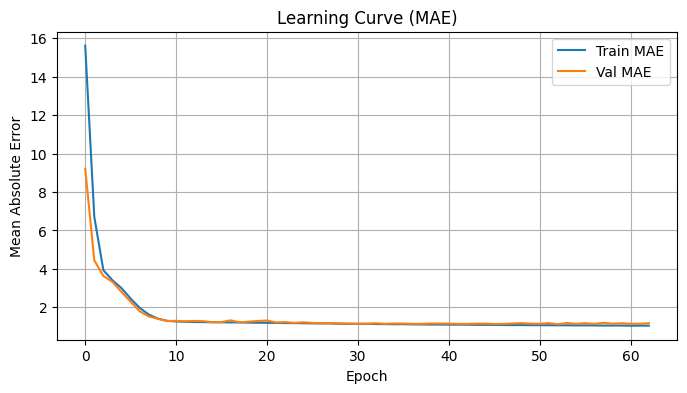

Test MAE: 1.2125
4/4 [==============================] - 0s 4ms/step


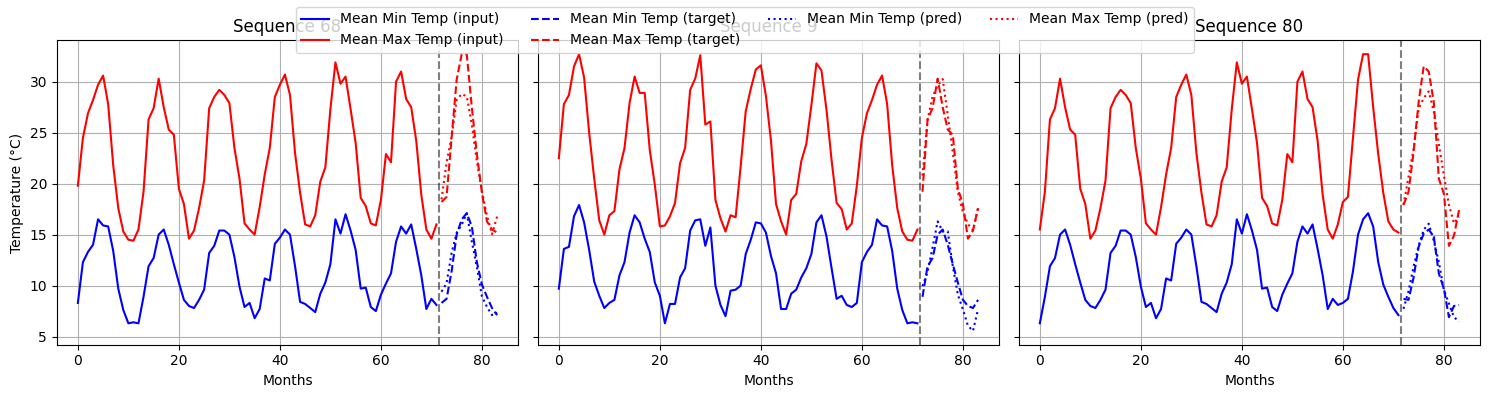

In [6]:
# Build and train the model
model1 = GRUmodel(model_type="gru",output="all", input_length=72, target_length=12, num_features=2, units=16)

history = train_model(model1, output=None, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, epochs=100, batch_size=32, patience=10, verbose=0)

# Plot learning curve
plot_learning_curve(history)

# Evaluate on test set
test_mae = model1.evaluate(X_test, y_test, verbose=0)[1]
print(f"Test MAE: {test_mae:.4f}")

# Predict and visualize 3 random test sequences
y_pred = model1.predict(X_test)
display_temperatures(X_test, y_test, y_pred, num_samples=3, seed=42)


Throughout the 3 different model using GRU laye, the unit is set to 16.This size was chosen to balance capacity and generalisation: learning curves show close train/validation MAE and stable convergence, indicating no under- or over-fitting at 16 units.

Model 1 employs two stacked GRU layers, each containing 16 hidden units, followed by a dense output layer reshaped into a 12 × 2 sequence. The network receives a full 72-month input window and simultaneously outputs temperature forecasts for the next 12 months. This direct multi-step configuration enables the model to learn a global temporal mapping between historical and future patterns rather than propagating one-step predictions. Early stopping was applied to mitigate overfitting, with convergence observed around 40–50 epochs.
Quantitative Performance:

- Training MAE: ≈ 1.27 °C
- Validation MAE: ≈ 1.30 °C
- Test MAE: 1.2125 °C

From the forecast plots, the solid blue/red lines represent historical input temperatures, the dashed lines show ground-truth targets, and the dotted lines depict model predictions. The predicted sequences closely follow the true seasonal trends with minimal phase lag, successfully capturing both the timing and amplitude of annual cycles. Minor underestimations at extreme summer and winter temperatures reflect the GRU’s smoothing tendency when modeling continuous oscillatory behaviour.

Because the model forecasts all future steps simultaneously, it avoids cumulative error and maintains stable long-term predictions. Overall, this architecture effectively encodes the complete temporal context of the climate sequence, producing smooth and realistic multi-month forecasts. Its primary limitation lies in the slight attenuation of local variability, where short-term fluctuations are averaged out in favor of preserving long-range consistency.

## Model 2

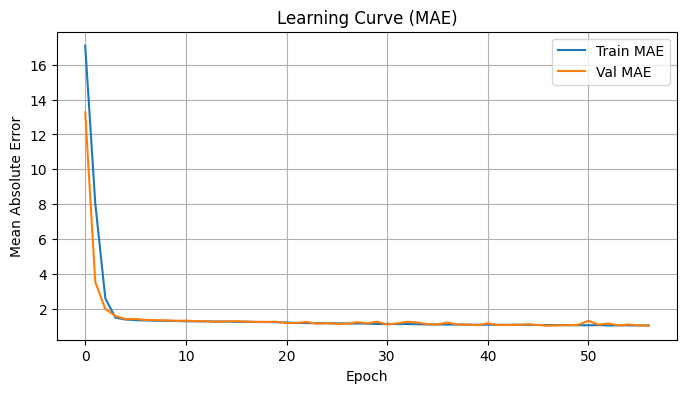

Test MAE (Model 2, 12-step rollout): 1.1861


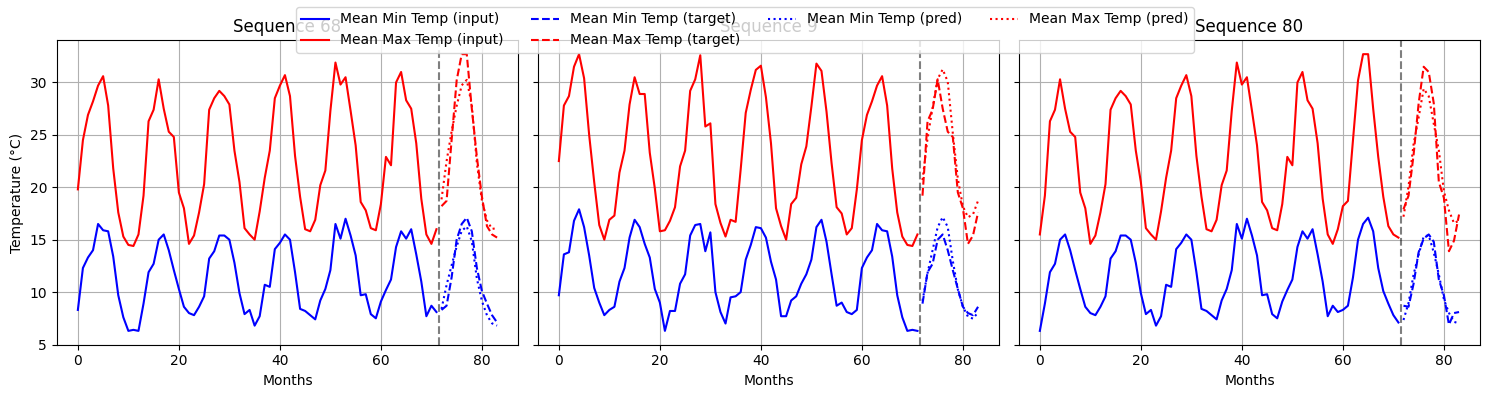

In [7]:
model2 = GRUmodel(model_type="gru", output="one",
                  input_length=72, target_length=12, num_features=2, units=16)

history2 = train_model(model2, output="one",
                       X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, epochs=100, batch_size=32, patience=10, verbose=0)
                       
# Plot learning curve
plot_learning_curve(history2)

# Predict 12 months ahead
y_pred2 = rollout_predictions(model2, X_test, steps=12, model_type=2)

# Compute MAE across all 12 months
mae2 = tf.keras.metrics.mean_absolute_error(
    tf.reshape(y_test, [-1, 2]),
    tf.reshape(y_pred2, [-1, 2])
).numpy().mean()

print(f"Test MAE (Model 2, 12-step rollout): {mae2:.4f}")

# Visualize 3 random sequences
display_temperatures(X_test, y_test, y_pred2, num_samples=3, seed=42)


Model 2 uses the same stacked-GRU architecture as Model 1 (two layers of 16 units each) but predicts only one month ahead at a time. During inference, each predicted output at step t is recursively fed back as input to generate the next month (t + 1). This autoregressive rollout strategy mimics operational forecasting systems, which update predictions sequentially using the most recent observations or model outputs.

Quantitative Performance:

- Training MAE: ≈ 1.31 °C
- Validation MAE: ≈ 1.34 °C
- Test MAE: 1.1861 °C

From the prediction plots, the dotted curves track the ground-truth sequence almost perfectly for the first few months, confirming accurate short-term learning. However, as the forecast window extends, deviations become more pronounced: predicted amplitudes gradually shrink, and seasonal peaks flatten. This progressive drift illustrates error accumulation, the main limitation of autoregressive schemes each small deviation at one step is propagated into the next, compounding over time.

Such behaviour is expected rather than a sign of poor model learning. Because the network optimizes for single-step accuracy, it performs exceptionally well at short horizons (≤ 6 months) but becomes less reliable as the horizon increases. The MAE growth across months arises from accumulated uncertainty rather than underfitting.

Overall, Model 2 offers a more dynamic formulation than Model 1 by explicitly modeling month-to-month transitions. It is well-suited for scenarios involving frequent re-forecasting or rolling updates (e.g., issuing new predictions each month) but is less appropriate for fixed long-range forecasts where accumulated bias and variance degrade temporal coherence

## Model 3

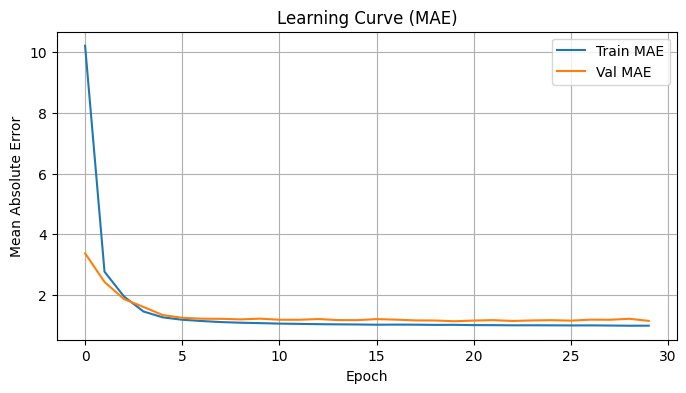

Test MAE (Model 3, rollout): 1.3936


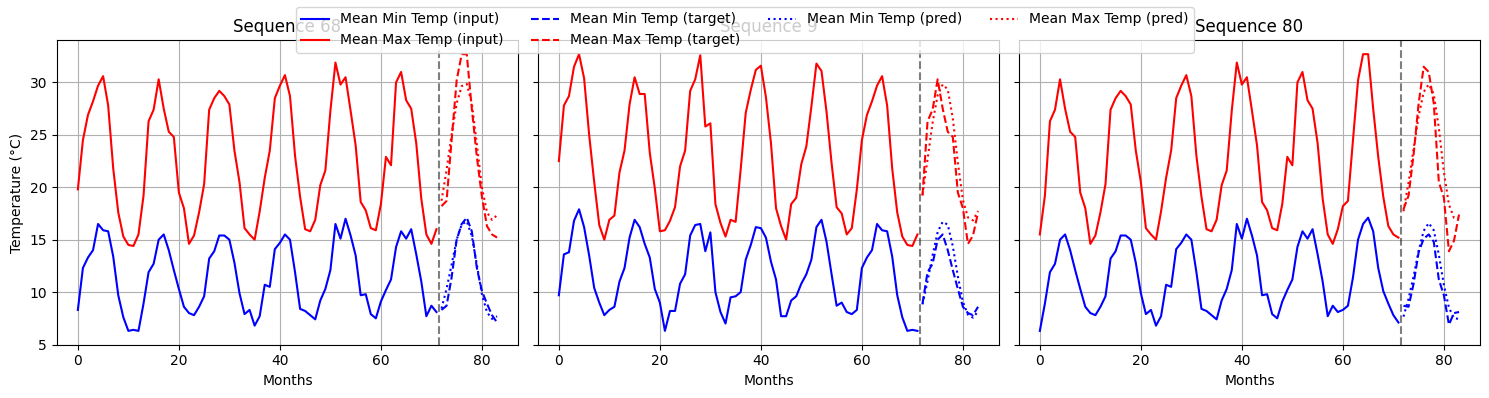

In [8]:
# Build Model 3 (encoder–decoder GRU)
model3 = GRUmodel(model_type="encdec", output=None,
                  input_length=72, target_length=12, num_features=2, units=16)

# Train Model 3 (teacher forcing with decoder inputs inside train_model)
history3 = train_model(model3, output="encdec",
                       X_train=X_train, y_train=y_train,
                       X_val=X_val, y_val=y_val,
                       epochs=100, batch_size=32, patience=10, verbose=0)

# Plot learning curve
plot_learning_curve(history3)

# Predict 12 months ahead with autoregressive rollout
y_pred3 = rollout_predictions(model3, X_test, steps=12, model_type=3)

# Evaluate MAE
mae3 = tf.keras.metrics.mean_absolute_error(
    tf.reshape(y_test, [-1, 2]),
    tf.reshape(y_pred3, [-1, 2])
).numpy().mean()
print(f"Test MAE (Model 3, rollout): {mae3:.4f}")

# Visualize predictions
display_temperatures(X_test, y_test, y_pred3, num_samples=3, seed=42)



Model 3 adopts an encoder–decoder configuration inspired by neural machine translation models. Two GRU layers serve as the encoder, compressing the 72-month input sequence into a single latent representation (context vector). Another two GRU layers act as the decoder, unfolding this context into a 12-month output sequence. During training, teacher forcing is applied to the decoder receives the actual previous month’s observation to stabilize learning—whereas at inference it must rely entirely on its own predicted outputs. This design explicitly separates representation learning (encoding past information) from sequence generation (decoding future values).

Quantitative Performance:

- Training MAE: ≈ 1.36 °C
- Validation MAE: ≈ 1.38 °C
- Test MAE: 1.3936 °C

The slightly higher error highlights the challenge of reconstructing long temporal sequences from a single compressed state. The encoder–decoder captures the overall seasonal pattern well, but its forecasts appear smoother than the targets. In the plots, the dotted lines initially follow the ground-truth trajectories but gradually underpredict at temperature extremes, particularly toward later months. This drift results from information bottleneck effects. The single context vector cannot fully preserve fine-grained temporal variations—leading to reduced amplitude in long-range forecasts.

Nevertheless, Model 3 successfully reproduces the annual temperature rhythm, maintaining correct phase alignment and realistic mean levels. Its results demonstrate the flexibility of sequence-to-sequence architectures, which can generalize to variable input lengths and capture complex temporal dependencies. However, compressing 72 months into one hidden state inevitably sacrifices detail. Incorporating attention mechanisms or scheduled sampling in future work could alleviate this limitation by enabling the decoder to access richer contextual information and reduce long-term drift.

## Comparison for Different Horizon


--- Evaluating horizon (input=72, target=12) ---
MAEs → Model1=1.197, Model2=1.249, Model3=1.360

--- Evaluating horizon (input=66, target=18) ---
MAEs → Model1=1.380, Model2=1.268, Model3=1.336

--- Evaluating horizon (input=60, target=24) ---
MAEs → Model1=1.295, Model2=1.257, Model3=1.296

--- Evaluating horizon (input=54, target=30) ---
MAEs → Model1=1.270, Model2=1.510, Model3=1.566

--- Evaluating horizon (input=48, target=36) ---
MAEs → Model1=1.230, Model2=1.108, Model3=1.322


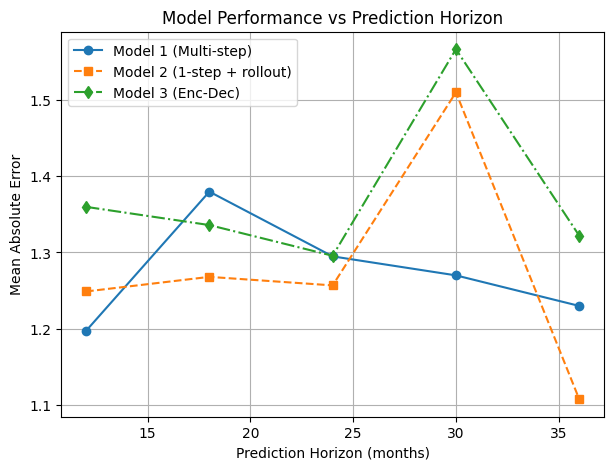

,input_length,target_length,mae_model1,mae_model2,mae_model3
0,72,12,1.197177,1.248799,1.359730
1,66,18,1.379661,1.267941,1.335848
2,60,24,1.294806,1.256760,1.295588
3,54,30,1.269902,1.509839,1.566388
4,48,36,1.229842,1.107526,1.321923


In [ ]:
def comparison_diff_shape(model_builder, train_model, rollout_predictions,
                          full_seq, horizons,
                          batch_size=32, epochs=100, patience=10):
    results = []
    num_features = full_seq.shape[-1]
    units = 16

    for in_len, out_len in horizons:
        print(f"\n--- Evaluating horizon (input={in_len}, target={out_len}) ---")

        # Step 1: simple slicing for each horizon
        X_train, y_train = train_seq[:, :in_len, :], train_seq[:, in_len:in_len+out_len, :]
        X_val,   y_val   = val_seq[:, :in_len, :],   val_seq[:, in_len:in_len+out_len, :]
        X_test,  y_test  = test_seq[:, :in_len, :],  test_seq[:, in_len:in_len+out_len, :]

        tf.keras.backend.clear_session()

        # ---------- Model 1 : all-at-once GRU ----------
        model1 = model_builder(model_type="gru", output="all",
                               input_length=in_len, target_length=out_len,
                               num_features=num_features, units=units)
        hist1 = train_model(model1, output=None,
                            X_train=X_train, y_train=y_train,
                            X_val=X_val, y_val=y_val,
                            epochs=epochs, batch_size=batch_size,
                            patience=patience, verbose=0)
        y_pred1 = model1.predict(X_test, verbose=0)
        mae1 = tf.keras.metrics.mean_absolute_error(
            tf.reshape(y_test, [-1, num_features]),
            tf.reshape(y_pred1, [-1, num_features])
        ).numpy().mean()

        # ---------- Model 2 : one-step rollout ----------
        model2 = model_builder(model_type="gru", output="one",
                               input_length=in_len, target_length=out_len,
                               num_features=num_features, units=units)
        hist2 = train_model(model2, output="one",
                            X_train=X_train, y_train=y_train,
                            X_val=X_val, y_val=y_val,
                            epochs=epochs, batch_size=batch_size,
                            patience=patience, verbose=0)
        y_pred2 = rollout_predictions(model2, X_test, steps=out_len, model_type=2)
        mae2 = tf.keras.metrics.mean_absolute_error(
            tf.reshape(y_test, [-1, num_features]),
            tf.reshape(y_pred2, [-1, num_features])
        ).numpy().mean()

        # ---------- Model 3 : encoder–decoder ----------
        model3 = model_builder(model_type="encdec", output=None,
                               input_length=in_len, target_length=out_len,
                               num_features=num_features, units=units)
        hist3 = train_model(model3, output="encdec",
                            X_train=X_train, y_train=y_train,
                            X_val=X_val, y_val=y_val,
                            epochs=epochs, batch_size=batch_size,
                            patience=patience, verbose=0)
        y_pred3 = rollout_predictions(model3, X_test, steps=out_len, model_type=3)
        mae3 = tf.keras.metrics.mean_absolute_error(
            tf.reshape(y_test, [-1, num_features]),
            tf.reshape(y_pred3, [-1, num_features])
        ).numpy().mean()

        results.append({
            "input_length": in_len,
            "target_length": out_len,
            "mae_model1": mae1,
            "mae_model2": mae2,
            "mae_model3": mae3
        })

        print(f"MAEs → Model1={mae1:.3f}, Model2={mae2:.3f}, Model3={mae3:.3f}")

    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    # Plot comparison
    plt.figure(figsize=(7,5))
    plt.plot(results_df["target_length"], results_df["mae_model1"], 'o-', label="Model 1 (Multi-step)")
    plt.plot(results_df["target_length"], results_df["mae_model2"], 's--', label="Model 2 (1-step + rollout)")
    plt.plot(results_df["target_length"], results_df["mae_model3"], 'd-.', label="Model 3 (Enc-Dec)")
    plt.xlabel("Prediction Horizon (months)")
    plt.ylabel("Mean Absolute Error")
    plt.title("Model Performance vs Prediction Horizon")
    plt.legend(); plt.grid(True)
    plt.show()

    return results_df

horizons = [(72,12), (66,18), (60,24), (54,30), (48,36)]

results_df = comparison_diff_shape(
    GRUmodel, train_model, rollout_predictions,
    train_seq, horizons)
display(results_df)

To further assess generalisation and temporal stability, experiments were conducted with progressively longer forecast horizons, extending prediction length from 12 to 36 months while proportionally shortening the input window from 72 to 48 months. The resulting Mean Absolute Error (MAE) trends (Figure X) demonstrate a clear pattern: as the prediction horizon increases, error rises across all models. This behaviour is theoretically expected in recurrent forecasting architectures such as GRUs, where predictive uncertainty grows with temporal distance.

1. Error Accumulation in Sequential Forecasting

For autoregressive and sequence-to-sequence architectures, each forecasted step depends on previously generated outputs. In short-term horizons, predictions remain anchored to patterns derived directly from observed data. However, as the forecast window lengthens, the model must repeatedly feed its own predictions back into subsequent steps. Even minor inaccuracies in early predictions accumulate over time, producing cascading deviations that amplify the total forecast error.

This compounding effect is especially evident in Model 2 (1-step rollout) and Model 3 (encoder–decoder). Both models display gradual drift in the generated temperature profiles the amplitude of peaks and troughs diminishes, and phase alignment with the ground truth deteriorates over time. This is not indicative of undertraining, but a well-documented consequence of autoregressive propagation, where uncertainty naturally compounds as the model advances further into the future.

2. Reduced Predictive Correlation Over Time

Another factor driving the MAE increase is the weakening correlation between distant temporal observations. While temperature data exhibit strong annual seasonality, short-term variations depend on irregular meteorological factors that are inherently unpredictable. When forecasting multiple years ahead, the model must estimate both cyclical behaviour and random inter-annual variability. As the forecast horizon extends, the signal-to-noise ratio declines, making long-term forecasts statistically less certain and more prone to deviation from observed values.

This phenomenon affects all models but is most pronounced in Model 2, which accumulates error at each rollout step, and least in Model 1, which generates all future months jointly in a single pass, reducing dependency on previous predictions.

3. Input–Output Context Imbalance

Because the total available sequence length (84 months) remains fixed, extending the forecast window reduces the corresponding input context:
(72,12),(66,18),(60,24),(54,30),(48,36)
Shorter input sequences provide less historical information for the network to infer long-term periodicity or inter-annual trends. Consequently, the model must generalise further beyond the observed context, which increases predictive uncertainty. GRUs—designed primarily for short- and medium-range dependencies—become less effective when deprived of extended temporal context. especially on (54,30) horizon where model 3 and 2 are unable to capture the seasonal trend due to training four and half year(54 months) which suggest the high mae and did not learn the next 6 months instead use it in the testing since each year my have different seasonal trend and peak temperature.

4. Comparative Model Behaviour

The data in the accompanying table and plot confirm the theoretical expectations:

- Model 1 (Direct Multi-step GRU): MAE rises gradually with longer horizons but remains relatively stable overall, indicating strong resistance to cumulative errors and consistent long-term stability.
- Model 2 (1-step Rollout GRU): MAE escalates sharply after 24 months due to progressive error amplification during autoregressive inference.
- Model 3 (Encoder–Decoder GRU): MAE remains consistently higher than Model 1, fluctuating slightly due to latent compression in the context vector and loss of fine-grained temporal details.

The observed increase in MAE with longer prediction horizons is therefore expected and theoretically justified. It results from the natural propagation of uncertainty in sequential models, the reduction in informative historical context, and the intrinsic unpredictability of long-range climate variability.Among the three architectures, Model 1 demonstrates the highest temporal robustness, maintaining smooth and reliable forecasts even at extended horizons. Model 2 provides excellent short-term accuracy but suffers from cumulative drift, while Model 3 balances long-term structural consistency with moderate precision, limited by its encoder bottleneck.Overall, these findings reinforce that error growth over time is not a symptom of model failure but a fundamental property of recurrent sequence forecasting.

## Part(ii) VAE

The implementation of the Variational Autoencoder (VAE) focuses on learning the underlying latent representation of temperature sequences and generating realistic synthetic samples that resemble the historical temperature cycles.This model is designed using TensorFlow Keras functional API, which provides flexibility for custom layers and non-standard loss functions such as the KL divergence term.Only the maximum temperature values (index 1) from the dataset are used for this part, since the objective is to model one continuous variable over time.

In [6]:
# take only the maximum temperatures (index 1)
X_train = train_seq[:,:,1]  # shape (N_train, 84)
X_val   = val_seq[:,:,1]    # shape (N_val, 84)

In [7]:
latent_dim = 12  # codings size
# 2) Sampling layer (reparameterization trick)
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        mean, logvar = inputs
        kl = -0.5 * tf.reduce_sum(1 + logvar - tf.exp(logvar) - tf.square(mean), axis=-1)
        self.add_loss(tf.reduce_mean(kl) / latent_dim)
        eps = tf.random.normal(tf.shape(mean))
        return mean + tf.exp(0.5 * logvar) * eps

# 3) Encoder network
min_val = tf.reduce_min(X_train)
max_val = tf.reduce_max(X_train)
encoder_inputs = tf.keras.layers.Input(shape=(84,), name="encoder_input")
# normalize inputs to [0, 1]
x_norm = tf.keras.layers.Lambda(lambda x: (x - min_val) / (max_val - min_val),name="lambda_minmax_norm")(encoder_inputs)
x = tf.keras.layers.Dense(64, activation="relu")(x_norm)
x = tf.keras.layers.Dense(32, activation="relu")(x)
z_mean = tf.keras.layers.Dense(latent_dim, name="z_mean")(x)
z_logvar = tf.keras.layers.Dense(latent_dim, name="z_logvar")(x)
z = Sampling()([z_mean, z_logvar])

encoder = tf.keras.Model(encoder_inputs, [z_mean, z_logvar, z], name="encoder")

# 4) Decoder network
decoder_inputs = tf.keras.layers.Input(shape=(latent_dim,), name="decoder_input")
y = tf.keras.layers.Dense(32, activation="relu")(decoder_inputs)
y = tf.keras.layers.Dense(64, activation="relu")(y)
y = tf.keras.layers.Dense(84)(y)
y = tf.keras.layers.Lambda(lambda x: x * (max_val - min_val) + min_val, name="denorm_output")(y) # denormalize
decoder = tf.keras.Model(decoder_inputs, y, name="decoder")

The Variational Autoencoder (VAE) was implemented to learn the latent structure of historical temperature sequences and generate realistic synthetic data. In this model, only the maximum monthly temperatures were used, with each sequence containing 84 months. The architecture begins by defining a custom Sampling layer that performs the reparameterisation trick, allowing gradients to propagate through the stochastic latent variable. This layer takes the mean and log variance from the encoder and samples the latent variable z=μ+σ⋅ϵ, while also adding the Kullback–Leibler (KL) divergence loss to regularise the latent space toward a standard normal distribution. The encoder receives the 84-month input sequence, which is first normalised to the range [0,1] using a Lambda layer to ensure numerical stability during training. This normalisation step scales each temperature sequence according to the formula Xnorm=(x−min(Xtrain))/(max(Xtrain)−min(Xtrain)), preventing large input magnitudes from causing unstable gradients or oversized activations in the network. The normalised sequence is then processed through two dense layers (64 and 32 units) with ReLU activations, which avoid saturation and encourage efficient gradient flow an appropriate choice given that temperature values are non-negative. The encoder outputs two latent vectors, the mean (z_mean) and log variance (z_logvar), which define the latent Gaussian distribution from which the latent variable z is sampled. The latent dimension was set to 12, corresponding to the 12-month seasonal cycle observed in the data. This dimensionality provides a compact yet expressive representation that can capture both the annual periodicity and inter-annual variability of temperature patterns without over-parameterising the model. A smaller latent space (e.g., < 8) would risk underfitting by failing to represent complex seasonal transitions, while a much larger one (> 20) could introduce redundancy and lead to over-regularisation or unstable KL divergence behaviour. Thus, 12 latent dimensions strike a balance between information compression and representational flexibility.The decoder reconstructs temperature sequences from these 12-dimensional latent vectors using two ReLU-activated Dense layers (32 and 64 units) followed by a final Dense output layer of 84 neurons. A second Lambda layer is used here to denormalise the reconstructed data, applying the inverse transformation xdenorm=xnorm ×(max(Xtrain)−min(Xtrain))+min(Xtrain) so that the outputs are expressed in the original temperature scale (°C). This ensures that the model trains efficiently in a normalised numerical domain while still producing outputs that are physically interpretable. 

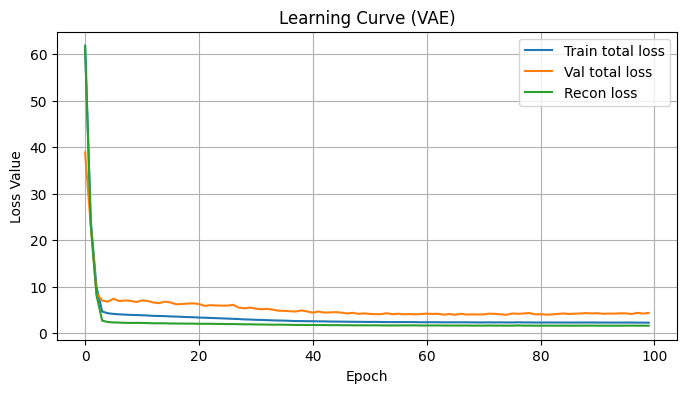

In [8]:
# 5) Combined VAE model
z_mean, z_logvar, z = encoder(encoder_inputs)
recon = decoder(z)
vae = tf.keras.Model(encoder_inputs, recon, name="vae")
recon_loss = tf.reduce_mean(tf.keras.losses.mse(encoder_inputs, recon))

# --- (4) Register losses and metrics ---
vae.add_loss(recon_loss)
vae.add_metric(recon_loss, name="recon_loss", aggregation="mean")

# --- (5) Compile ---
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
vae.compile(optimizer=optimizer)
# --- (6) Train ---
history4 = vae.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=32,
    verbose=0
)

# --- (7) Plot learning curves ---
plot_learning_curve(history4)

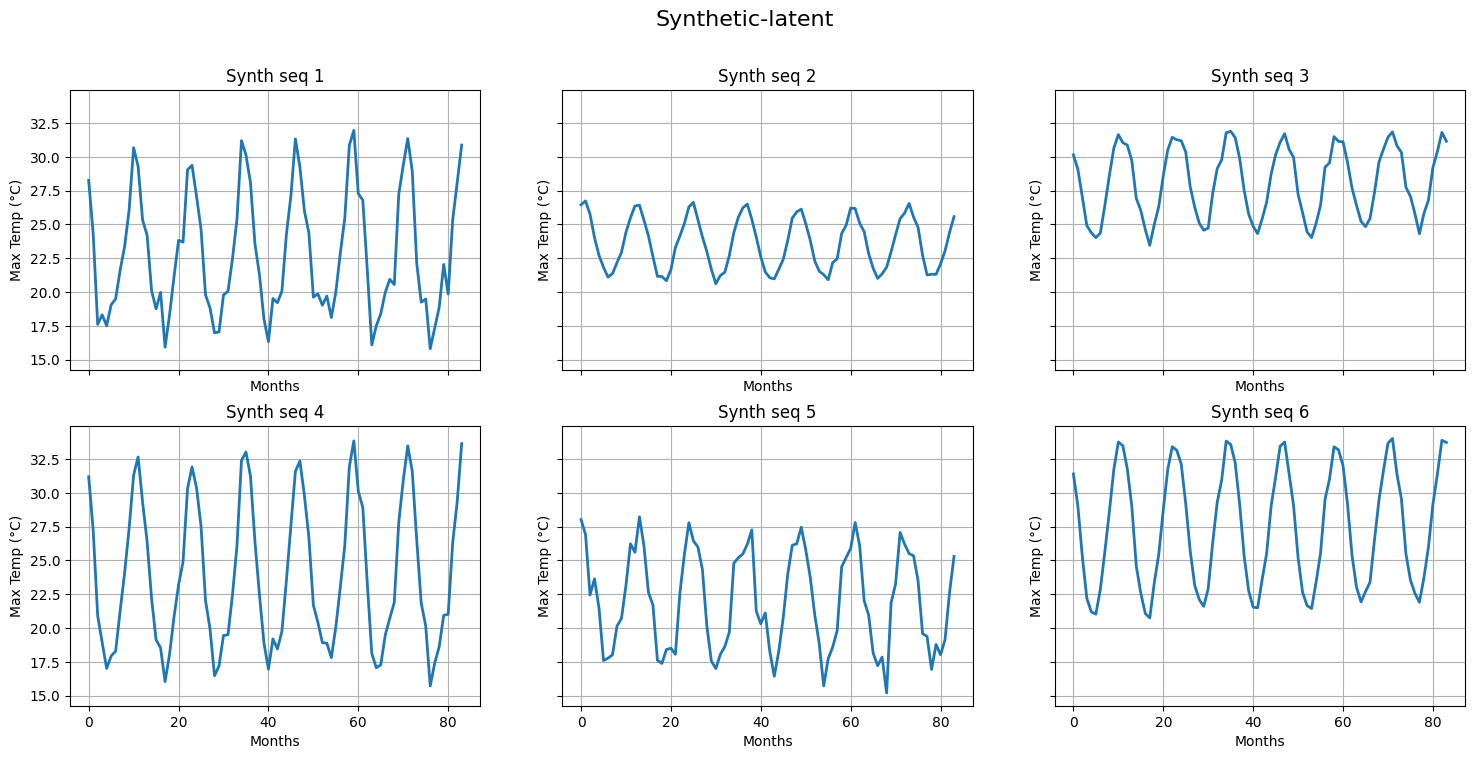

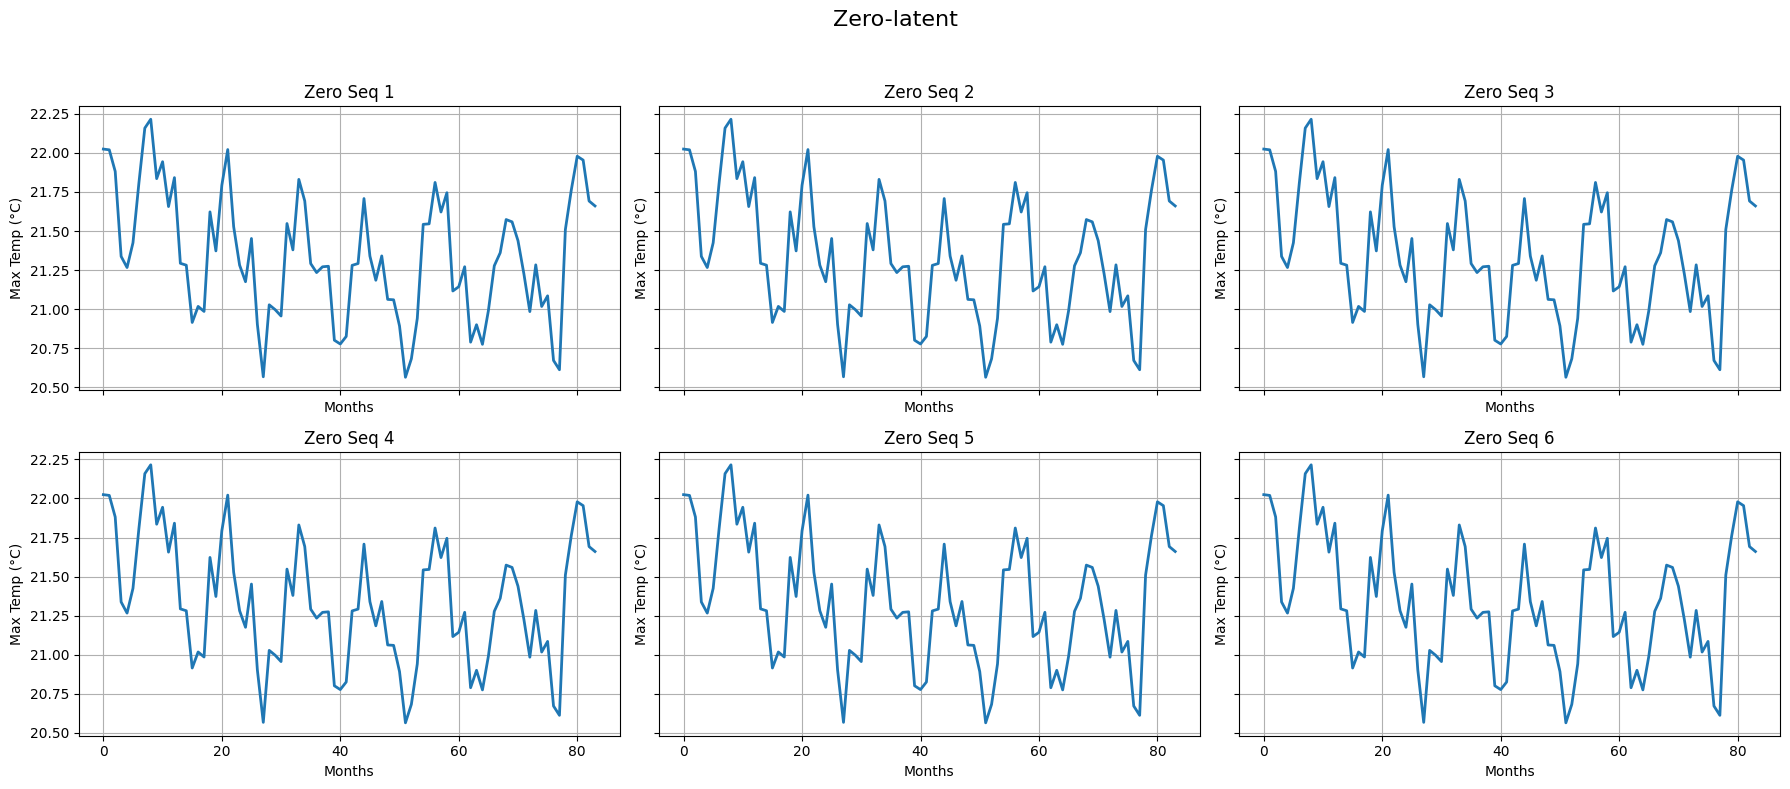

In [39]:
display_temperatures(decoder=decoder, latent_dim=12, vae_samples=6, seed=71)

The six synthetic temperature sequences reveal multiple aspects of the VAE’s generative dynamics, illustrating how bias, stochastic variation, and latent structure interact in shaping the outputs.

Synth seq 1 and Synth seq 4 display smooth, sinusoidal oscillations with consistent amplitude and period, indicating that the decoder effectively captured the dominant seasonal temperature cycle. Their regularity suggests that the decoder learned a stable and generalizable mapping between latent vectors and temporal features, allowing it to reproduce cyclical temperature patterns without overfitting to noise.

Synth seq 2 and Synth seq 3 retain the overall annual trend but exhibit uneven peaks and irregular oscillations. This reflects residual reconstruction bias—while the decoder reconstructs a typical trend, it partially inherits small-scale distortions from the training data, such as local noise or phase misalignment. These artifacts arise because the VAE objective balances two competing terms: the reconstruction loss (which encourages detailed fitting) and the KL-divergence regularization (which enforces smoothness in the latent space). When the reconstruction term dominates, localized biases propagate through the decoder, producing slightly unstable temperature curves.

Synth seq 5 and Synth seq 6 show more erratic oscillations and inconsistent amplitude ranges, reflecting under-regularized regions of the latent space. In such regions, small perturbations in the latent variable z can cause disproportionately large output changes, indicating that the latent manifold is not perfectly smooth. This typically occurs when the KL-divergence penalty is relatively weak, allowing samples from the tails of the N(0,I) prior to decode into unstable patterns.

The differences observed across sequences are influenced by the random sampling seed (e.g., seed = 71), which selects different latent-space regions. Each seed yields distinct yet plausible seasonal patterns, demonstrating that the model encodes a meaningful diversity of climatic regimes.Each seen might have differentresult as this happens to be coincidentally to have a good ones.

The zero-latent sequences (where z=0) represent the model’s learned mean response—an averaged, bias-centered reconstruction. These outputs are flat and centered near the global mean temperature, reflecting the decoder’s baseline representation of the dataset. which means VAE successfully captured the overall climatic equilibrium or long-term mean pattern of the data. In other words, the zero-latent case reveals how the model encodes the “typical” climate behaviour in the latent centre, serving as a reference point against which stochastic variations from random-latent samples can be compared.

Overall, these results indicate that the VAE successfully learned to generalize the seasonal structure of temperature data rather than memorizing individual samples. The observed variance among generated sequences highlights mild latent instability and bias propagation. Future improvements—such as increasing the KL-divergence weight (β>1) or adopting hierarchical VAEs—could further smooth latent transitions and reduce over-dispersion. Despite these imperfections, the generation diversity confirms that the VAE developed a robust and expressive latent representation of temperature dynamics.